# Lowering the Barrier to AI Research - Introduction to AI-Assisted Coding: Prompt Engineering with LLMs in Google Colab

## Overview
This hands-on workshop introduces participants to using large language models (LLMs) as interactive coding assistants. Using Gemini within Google Colab, participants will learn how to guide AI systems through prompt engineering to generate, modify, and debug Python code while developing analytical workflows. The workshop focuses on practical strategies for interacting with LLMs as coding partners without requiring advanced programming expertise.

Geospatial data analysis will be used as a case study to demonstrate these techniques. Participants will work through an example that integrates satellite remote sensing data from NASA’s Harmonized Landsat–Sentinel (HLS) NDVI product with U.S. Census socioeconomic datasets to explore environmental justice indicators. Through this example, participants will develop a simple workflow in Google Colab that demonstrates how LLM-assisted coding can support data integration, analysis, and visualization.

By the end of the session, participants will have gained practical experience collaborating with LLMs as coding assistants and will understand how similar approaches can be applied to their own data analysis workflows.


## Learning Objectives
- Use large language models (LLMs) to generate and modify Python code in Google Colab
- Apply prompt-engineering strategies to iteratively debug code, resolve errors, and improve analytical workflows
- Integrate satellite remote sensing data (NDVI from NASA’s Harmonized Landsat–Sentinel dataset) with U.S. Census socioeconomic datasets
- Summarize and visualize spatial patterns using maps, tables, and simple statistical comparisons
- Develop skills for using AI to write and refine code while creating a reproducible workflow that can be adapted to other geospatial datasets and research questions.

## Prerequisites
- Basic familiarity with data analysis or geospatial concepts (no coding experience required)
- A laptop with internet access
- A Google account to access Google Colab
- A great attitude!

## Part 1: Brief Introduction to Colab and Setting Up Your Environment and Working Directory

### Key Tasks
- Introduction to Google Colab and its features
- Install a suite of packages we will use in our workspace
- Set up our working directory
---



In [ ]:
# (Optional) To mount your Google Drive if you want to work from a Google Drive folder etc
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# 1. Clone the repo to the fast, temporary storage
!git clone https://github.com/CGC-UMCES/NAIRR-2026-Tutorial-Intro-Colab-LLM-Coding.git

Cloning into 'NAIRR-2026-Tutorial-Intro-Colab-LLM-Coding'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 44 (delta 21), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 8.13 MiB | 10.70 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [3]:
# 2. Change directory into the new repo folder
%cd /content/NAIRR-2026-Tutorial-Intro-Colab-LLM-Coding/

# 3. (Optional) Check to see your files are there
!ls

/content/NAIRR-2026-Tutorial-Intro-Colab-LLM-Coding
baltimore_region_acs_2022_epsg4269.csv
baltimore_region_acs_2022_epsg4269.geojson
baltimore_region_HLSS30_mean_summer_2022_NDVI_epsg4269_clip.tif
cheat_LLM_coding_tutorial.ipynb
LICENSE
Presentation_AI_Unlocked_2026.pdf
prompts_LLM_coding_tutorial.ipynb
README.md


In [ ]:
# (Optional) Install required packages
# Not important when in Colab but important for sharing your notebook externally!!
# !pip install pandas geopandas numpy matplotlib seaborn scikit-learn rasterio earthpy rasterstats

####<font color="#FF69B4">PROMPT: Check the working directory for my notebook and print the contents</font>





In [4]:
%pwd
!ls

baltimore_region_acs_2022_epsg4269.csv
baltimore_region_acs_2022_epsg4269.geojson
baltimore_region_HLSS30_mean_summer_2022_NDVI_epsg4269_clip.tif
cheat_LLM_coding_tutorial.ipynb
LICENSE
Presentation_AI_Unlocked_2026.pdf
prompts_LLM_coding_tutorial.ipynb
README.md


## Part 2: Working with Census Data to Create a Social Vulnerability Index (SVI)

In this section, you'll work with a subset of the 2022 Census data from the Baltimore, MD region and create a basic social vulnerability index.

### Key Tasks
- Read in a .geojson file (essentially a spatial dataframe like a shapefile)
- Learn to investigate variables
- Create and view a simple social vulnerability index (SVI)


---



####<font color="#FF69B4">PROMPT: Import a .geojson file with census data in it named baltimore_region_acs_2022_epsg4269.geojson from my working directory and get some info about it. I would like the variable to be called gdf</font>

In [5]:
import geopandas as gpd

# Define the filename
geojson_file = 'baltimore_region_acs_2022_epsg4269.geojson'

# Load the GeoJSON file into a GeoDataFrame
gdf = gpd.read_file(geojson_file)

# Get information about the GeoDataFrame
print("\nGeoDataFrame Info:")
gdf.info()

# Display the first 5 rows of the GeoDataFrame
print("\nFirst 5 rows of the GeoDataFrame:")
print(gdf.head())


GeoDataFrame Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   total_population          414 non-null    int32   
 1   median_household_income   414 non-null    int32   
 2   population_below_poverty  414 non-null    int32   
 3   renter_occupied_units     414 non-null    int32   
 4   total_occupied_units      414 non-null    int32   
 5   white_population          414 non-null    int32   
 6   black_population          414 non-null    int32   
 7   hispanic_population       414 non-null    int32   
 8   county_fips               414 non-null    object  
 9   tract_code                414 non-null    object  
 10  geometry                  414 non-null    geometry
dtypes: geometry(1), int32(8), object(2)
memory usage: 22.8+ KB

First 5 rows of the GeoDataFrame:
   total_population  median_household_in

####<font color="#FF69B4">PROMPT: Calculate three more metrics that include the proportion of people in poverty, the proportion of renters, and the proportion of the population that is nonwhite and add to gdf<font>

Specifically calulate them in the following way:

gdf['prop_poverty'] = (gdf['population_below_poverty'] / gdf['total_population'])

gdf['prop_renter'] = (gdf['renter_occupied_units'] / gdf['total_occupied_units'])

gdf['prop_nonwhite'] = 1 - (gdf['white_population'] / gdf['total_population'])
<font>

In [6]:
# Calculate the proportion of people in poverty
gdf['prop_poverty'] = (gdf['population_below_poverty'] / gdf['total_population'])

# Calculate the proportion of renters
gdf['prop_renter'] = (gdf['renter_occupied_units'] / gdf['total_occupied_units'])

# Calculate the proportion of the population that is nonwhite
gdf['prop_nonwhite'] = 1 - (gdf['white_population'] / gdf['total_population'])

####<font color="skyblue">CHALLENGE: Can you prompt the LLM to show only the first 10 rows of gdf and only for the new columns you just created?</font>

In [7]:
# Display the first 10 rows of the new columns
print(gdf[['prop_poverty', 'prop_renter', 'prop_nonwhite']].head(10))

   prop_poverty  prop_renter  prop_nonwhite
0      0.064765     0.498686       0.548993
1      0.161337     0.131498       0.517422
2      0.090196     0.261656       0.623856
3      0.049133     0.321178       0.557322
4      0.030110     0.306018       0.252332
5      0.091175     0.268251       0.746918
6      0.035847     0.558242       0.814586
7      0.105980     0.213259       0.782702
8      0.138301     0.215616       0.884183
9      0.169054     0.516349       0.755492


####<font color="#FF69B4">PROMPT: Plot the data from the three new columns we just created side-by-side using the viridis colormap<font>

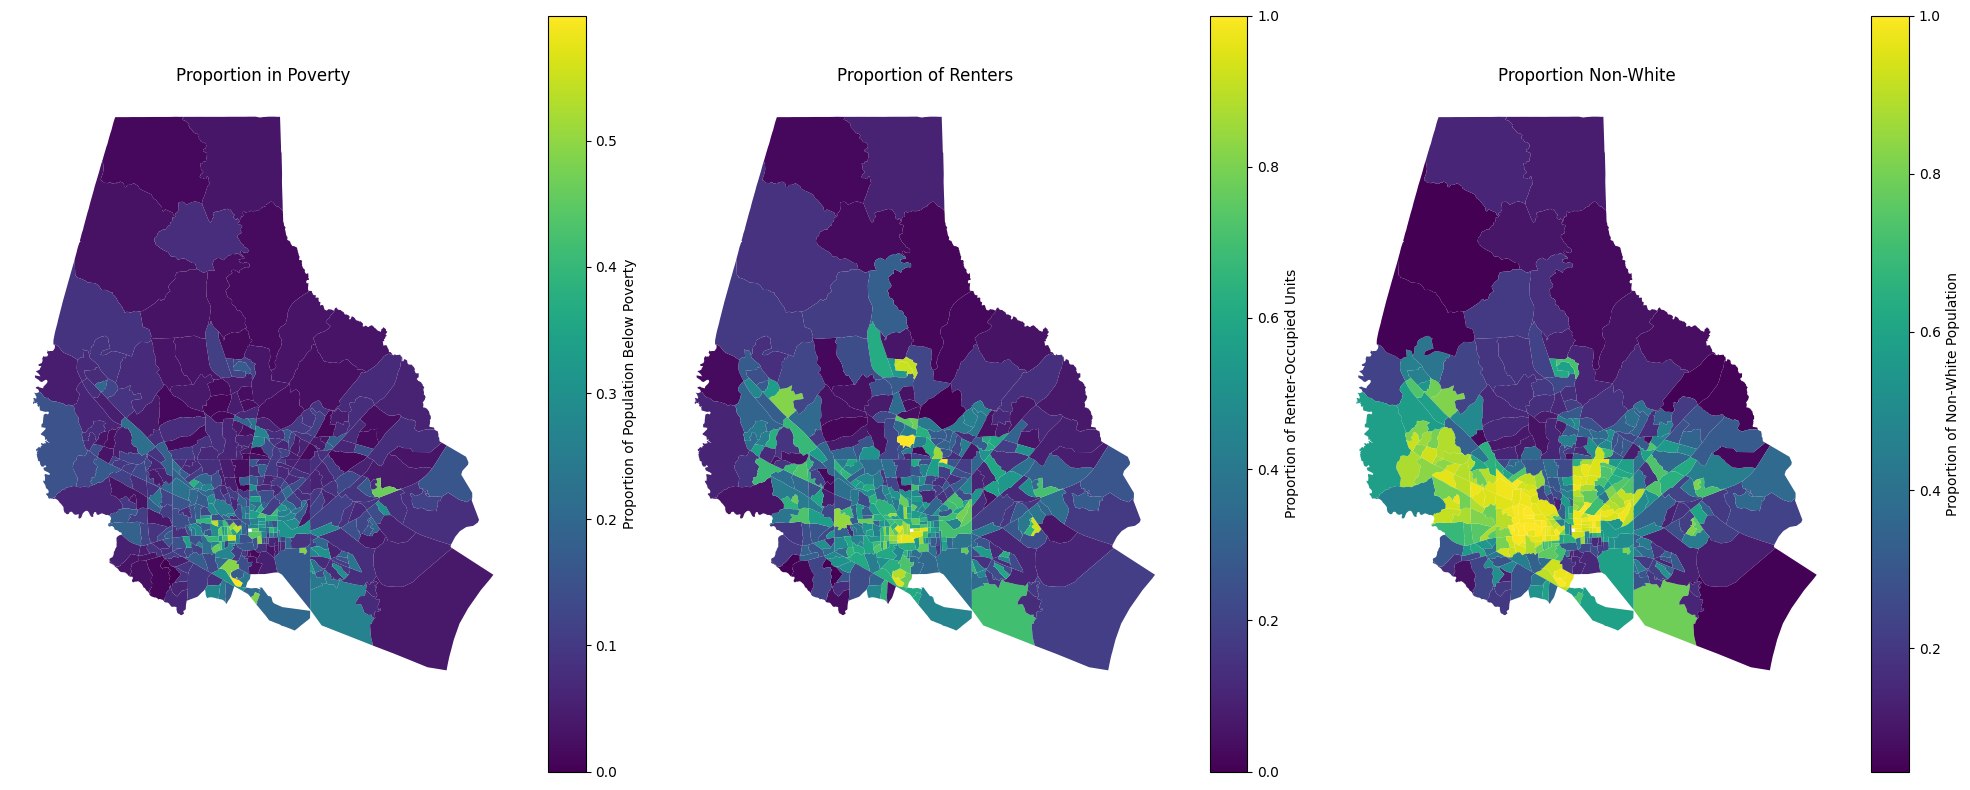

In [8]:
import matplotlib.pyplot as plt

# Create subplots for the three new columns
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Plot prop_poverty
gdf.plot(column='prop_poverty', cmap='viridis', legend=True, ax=axes[0],
         legend_kwds={'label': "Proportion of Population Below Poverty", 'orientation': "vertical"})
axes[0].set_title('Proportion in Poverty')
axes[0].set_axis_off()

# Plot prop_renter
gdf.plot(column='prop_renter', cmap='viridis', legend=True, ax=axes[1],
         legend_kwds={'label': "Proportion of Renter-Occupied Units", 'orientation': "vertical"})
axes[1].set_title('Proportion of Renters')
axes[1].set_axis_off()

# Plot prop_nonwhite
gdf.plot(column='prop_nonwhite', cmap='viridis', legend=True, ax=axes[2],
         legend_kwds={'label': "Proportion of Non-White Population", 'orientation': "vertical"})
axes[2].set_title('Proportion Non-White')
axes[2].set_axis_off()

plt.tight_layout()
plt.show()

####<font color="#FF69B4">PROMPT: Change the colormaps to "turbo", reduce the size of the colorbars, and make the font slightly larger<font>

####<font color="skyblue">CHALLENGE: Is there anything you would change about the way the plots look (e.g., colorbar size, font size, colormap, etc)? Ask the LLM and customize away! NOTE: If you get errors you can hit the "Explain Error" button in the lower left after the error and feed it right back into Gemini who will then try to correct your code!</font>

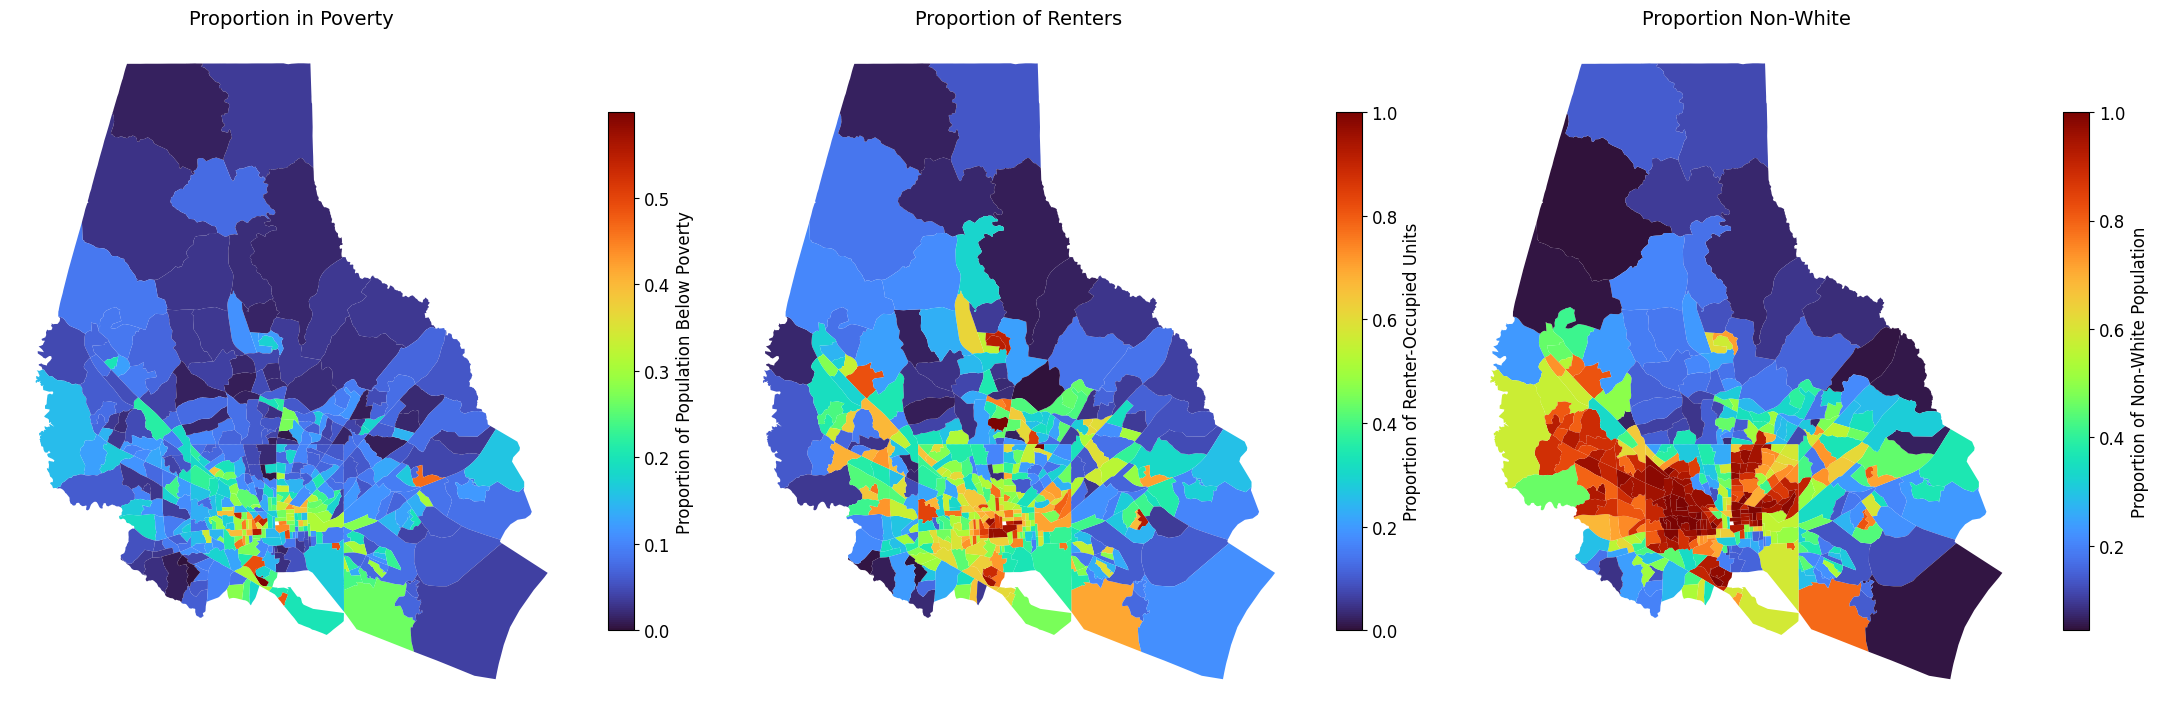

In [10]:
import matplotlib.pyplot as plt

# Set a global font size for better readability
plt.rcParams.update({'font.size': 12})

# Create subplots for the three new columns
fig, axes = plt.subplots(1, 3, figsize=(22, 9))

# Define the new colormap
new_cmap = 'turbo'

# Define common legend keywords for smaller colorbars and improved font size
legend_kwargs = {
    'label': "", # Label will be set individually per plot
    'orientation': "vertical",
    'shrink': 0.6,  # Reduce colorbar size relative to the plot
    'aspect': 20   # Control the width of the colorbar
    # Removed 'fontsize' from here as it's not a direct argument for matplotlib.colorbar.Colorbar
}

# Plot prop_poverty
poverty_plot = gdf.plot(column='prop_poverty', cmap=new_cmap, legend=True, ax=axes[0],
                        legend_kwds={**legend_kwargs, 'label': "Proportion of Population Below Poverty"})
axes[0].set_title('Proportion in Poverty', fontsize=14)
axes[0].set_axis_off()

# Plot prop_renter
renter_plot = gdf.plot(column='prop_renter', cmap=new_cmap, legend=True, ax=axes[1],
                       legend_kwds={**legend_kwargs, 'label': "Proportion of Renter-Occupied Units"})
axes[1].set_title('Proportion of Renters', fontsize=14)
axes[1].set_axis_off()

# Plot prop_nonwhite
nonwhite_plot = gdf.plot(column='prop_nonwhite', cmap=new_cmap, legend=True, ax=axes[2],
                         legend_kwds={**legend_kwargs, 'label': "Proportion of Non-White Population"})
axes[2].set_title('Proportion Non-White', fontsize=14)
axes[2].set_axis_off()

plt.tight_layout()
plt.show()

####<font color="#FF69B4">PROMPT: Create a Social Vulnerability Index (SVI) from my three new metrics and plot it</font>

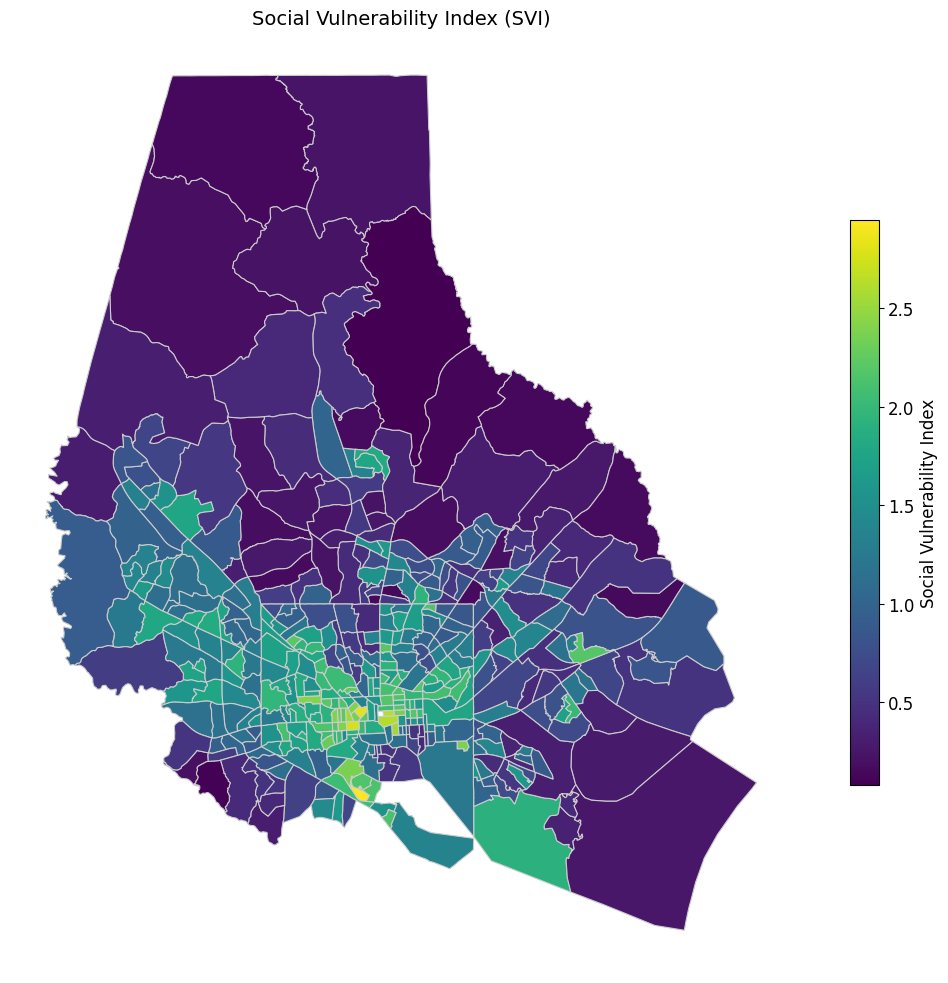

In [11]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Select the columns to be used for SVI
svi_metrics = ['prop_poverty', 'prop_renter', 'prop_nonwhite']

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the selected metrics
gdf[svi_metrics] = scaler.fit_transform(gdf[svi_metrics])

# Create the SVI by summing the scaled metrics
gdf['SVI'] = gdf[svi_metrics].sum(axis=1)

# Plot the SVI
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Set a global font size for better readability
plt.rcParams.update({'font.size': 12})

# Define common legend keywords for smaller colorbars and improved font size
legend_kwargs = {
    'label': "Social Vulnerability Index",
    'orientation': "vertical",
    'shrink': 0.6,  # Reduce colorbar size relative to the plot
    'aspect': 20   # Control the width of the colorbar
}

# Plot SVI
gdf.plot(column='SVI', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
         legend_kwds=legend_kwargs)
ax.set_title('Social Vulnerability Index (SVI)', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

####<font color="#FF69B4">PROMPT: What did the MinMaxScaler do to the data? Can you compare the values from before and after it was applied?</font>

In [12]:
# The SVI metrics were already identified and scaled in the previous cell.
# The 'gdf' GeoDataFrame now contains the scaled values in these columns.
svi_metrics = ['prop_poverty', 'prop_renter', 'prop_nonwhite']

# Print a summary of what MinMaxScaler does
print("What MinMaxScaler does:")
print("MinMaxScaler transforms features by scaling each feature to a given range, typically 0 to 1.")
print("This means that for each selected column, the original minimum value becomes 0, and the original maximum value becomes 1.")
print("All intermediate values are scaled proportionally within this new 0-1 range.")
print("This is often done to bring all features to a similar scale, which is important for many machine learning algorithms and also for combining metrics into an index like SVI.")

print("\n--- Current (Scaled) Data Overview ---")
print("Due to in-place application of MinMaxScaler, the original unscaled values for 'prop_poverty', 'prop_renter', and 'prop_nonwhite' are no longer directly available in the 'gdf' GeoDataFrame under their original names.")
print("However, we can inspect the characteristics of the *scaled* data to see the effect of the transformation.")

# Display min and max for the scaled columns to show they are now between 0 and 1
print("\nRange of scaled metrics:")
for col in svi_metrics:
    print(f"  {col}: Min = {gdf[col].min():.4f}, Max = {gdf[col].max():.4f}")

# Display the first few rows of the scaled data
print("\nFirst 5 rows of the scaled metrics (after MinMaxScaler application):")
print(gdf[svi_metrics].head())

What MinMaxScaler does:
MinMaxScaler transforms features by scaling each feature to a given range, typically 0 to 1.
This means that for each selected column, the original minimum value becomes 0, and the original maximum value becomes 1.
All intermediate values are scaled proportionally within this new 0-1 range.
This is often done to bring all features to a similar scale, which is important for many machine learning algorithms and also for combining metrics into an index like SVI.

--- Current (Scaled) Data Overview ---
Due to in-place application of MinMaxScaler, the original unscaled values for 'prop_poverty', 'prop_renter', and 'prop_nonwhite' are no longer directly available in the 'gdf' GeoDataFrame under their original names.
However, we can inspect the characteristics of the *scaled* data to see the effect of the transformation.

Range of scaled metrics:
  prop_poverty: Min = 0.0000, Max = 1.0000
  prop_renter: Min = 0.0000, Max = 1.0000
  prop_nonwhite: Min = 0.0000, Max = 1.

####<font color="#FF69B4">PROMPT: Plot a histogram of the SVI data</font>

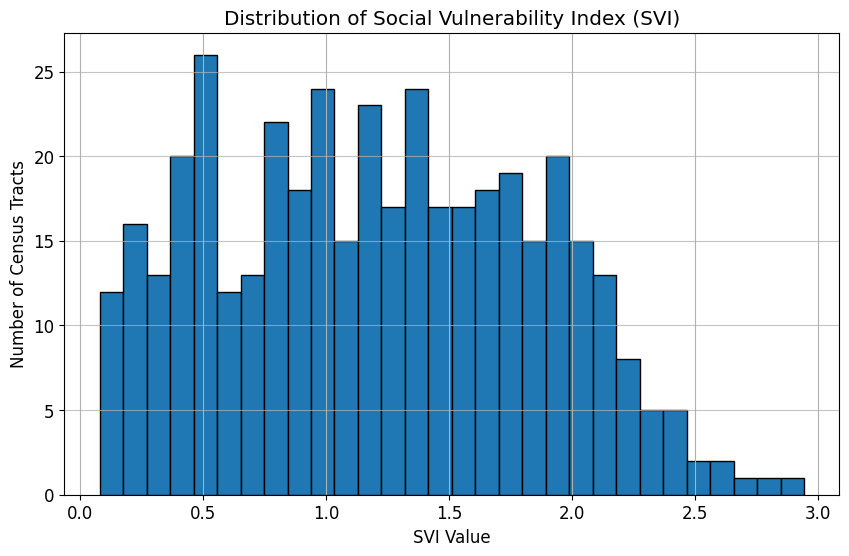

In [13]:
import matplotlib.pyplot as plt

# Create a histogram of the SVI data
plt.figure(figsize=(10, 6))
gdf['SVI'].hist(bins=30, edgecolor='black') # You can adjust the number of bins
plt.title('Distribution of Social Vulnerability Index (SVI)')
plt.xlabel('SVI Value')
plt.ylabel('Number of Census Tracts')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Part 3: Using a Detailed Prompt to Integrate Harmonized Landsat Sentinel-2 NDVI Data with Census Data to Illuminate Patterns of Social Vulnerability

In this section, you will work with a summer 2022 Normalized Difference Vegetation Index (NDVI) composite dataset derived from Harmonized Landsat Sentinel-2 [(HLS info)](https://hls.gsfc.nasa.gov/) and integrate it with the 2022 Census data for deeper exploration in the Baltimore, MD region.

### Key Tasks
- Import and view a geotiff raster file
- Extract NDVI statistics for each census tract and merge data into new colums
- Calculate a Green Space Inequity Index and view it
- Create a list of high priority environmental justice areas

### NDVI Primer
NDVI (Normalized Difference Vegetation Index) is a widely used remote sensing index that quantifies vegetation health and density using satellite or aerial imagery. It is calculated from the visible and near-infrared light reflected by vegetation.
<br>
<br>

📊 NDVI Formula:
$$
\text{NDVI} = \frac{(NIR - RED)}{(NIR + RED)}
$$

- NIR = Reflectance in the near-infrared spectrum (plants strongly reflect this light)

- RED = Reflectance in the red spectrum (plants absorb this light for photosynthesis)
<br>

🌱 NDVI Values:
NDVI values range from -1 to +1, and they indicate:

| NDVI Value    | Interpretation                           |
| ------------- | ---------------------------------------- |
| **< 0**       | Water, clouds, snow, or bare soil        |
| **0.1 – 0.2** | Sparse vegetation (e.g., shrubs)         |
| **0.2 – 0.5** | Moderate vegetation (e.g., grassland)    |
| **0.5 – 0.9** | Dense, healthy vegetation (e.g., forest) |
<br>
<br>

🛰️ Why is NDVI Useful?
- Environmental Monitoring: Assess drought, deforestation, and land degradation.
- Agriculture: Monitor crop health and stress.
- Urban Planning: Evaluate green space distribution.
- Climate Studies: Understand carbon sinks and land surface processes.

---

####<font color="#FF69B4">PROMPT: Load my NDVI geotiff from the working directory and plot the data</font>

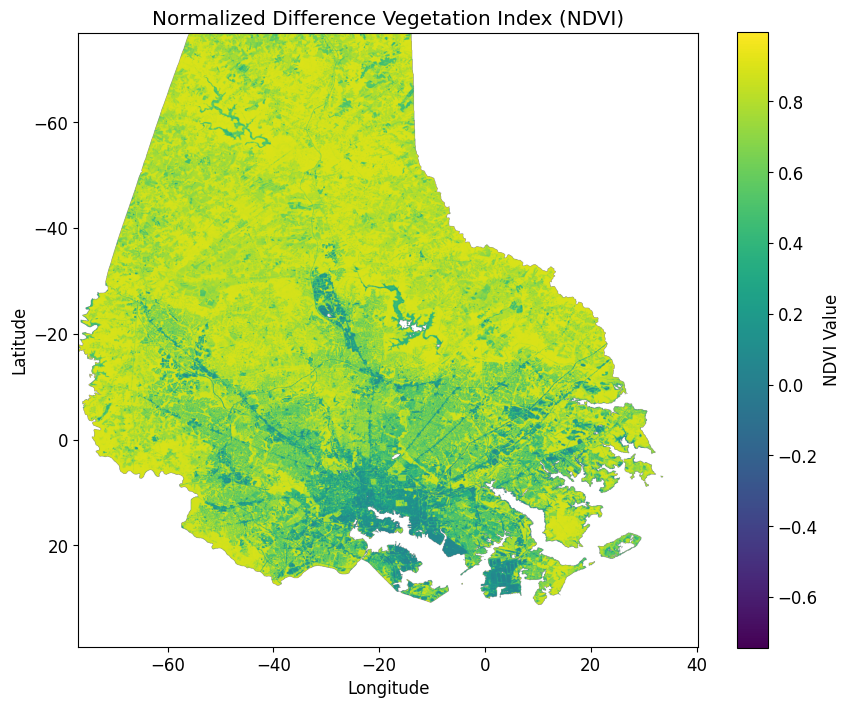

In [15]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Define the filename for the NDVI GeoTIFF
ndvi_file = 'baltimore_region_HLSS30_mean_summer_2022_NDVI_epsg4269_clip.tif'

# Open the GeoTIFF file
with rasterio.open(ndvi_file) as src:
    # Read the data from the first band
    ndvi_data = src.read(1)
    # Get the transform for plotting extent
    transform = src.transform

# Replace nodata values (-9999) with NaN for proper visualization and analysis
ndvi_data[ndvi_data == -9999.] = np.nan

# Plot the NDVI data
plt.figure(figsize=(10, 8))
plt.imshow(ndvi_data, cmap='viridis', extent=[transform.c, transform.f + transform.a * src.width, transform.f + transform.e * src.height, transform.c], origin='upper')
plt.colorbar(label='NDVI Value')
plt.title('Normalized Difference Vegetation Index (NDVI)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

####<font color="#FF69B4">PROMPT: Extract statistics from the ndvi dataset for each tract in my census data and add the data as new columns into my census dataset gdf. Also make sure that the nodata is set for all values equal to -9999 so they aren't being considered</font>

In [22]:
import rasterio
import rasterstats
import pandas as pd
import numpy as np

# Define the filename for the NDVI GeoTIFF
ndvi_file = 'baltimore_region_HLSS30_mean_summer_2022_NDVI_epsg4269_clip.tif'

# Open the GeoTIFF file to get its properties (data, transform, crs)
with rasterio.open(ndvi_file) as src:
    ndvi_data = src.read(1) # Read the raw data
    transform = src.transform
    crs = src.crs

# Replace nodata values (-9999) with NaN for statistics calculation, as previously discussed
# This step ensures these values are ignored by zonal_stats
ndvi_data[ndvi_data == -9999.] = np.nan

# Perform zonal statistics
# We'll calculate the mean, median, min, max, and count for each polygon in gdf
# Ensure gdf has the same CRS as the raster for accurate spatial operations
# Assuming gdf's CRS is already set and compatible or will be handled if not.
# For consistency with prior steps, let's explicitly reproject if necessary.
if gdf.crs != crs:
    gdf_projected = gdf.to_crs(crs)
else:
    gdf_projected = gdf

zonal_stats_list = rasterstats.zonal_stats(
    vectors=gdf_projected['geometry'],
    raster=ndvi_data,
    affine=transform,
    stats=['mean', 'median', 'min', 'max', 'count'],
    nodata=np.nan, # Explicitly tell zonal_stats to ignore NaN values
    all_touched=True # Include pixels touched by the polygon boundary
)

# Convert the list of dictionaries to a DataFrame
zonal_stats_df = pd.DataFrame(zonal_stats_list)

# Merge the statistics back into the original GeoDataFrame 'gdf'
# Assuming gdf's index aligns with the order of geometries processed by zonal_stats
gdf['ndvi_mean'] = zonal_stats_df['mean']
gdf['ndvi_median'] = zonal_stats_df['median']
gdf['ndvi_min'] = zonal_stats_df['min']
gdf['ndvi_max'] = zonal_stats_df['max']
gdf['ndvi_pixel_count'] = zonal_stats_df['count']

print("NDVI statistics extracted and added to gdf. Here's a peek at the new columns:")
print(gdf[['ndvi_mean', 'ndvi_median', 'ndvi_min', 'ndvi_max', 'ndvi_pixel_count']].head())

NDVI statistics extracted and added to gdf. Here's a peek at the new columns:
   ndvi_mean  ndvi_median  ndvi_min  ndvi_max  ndvi_pixel_count
0   0.539342     0.548629  0.047534  0.934855              1427
1   0.541443     0.576517  0.039273  0.909634               859
2   0.605141     0.625927  0.048351  0.927050              1751
3   0.622475     0.659248  0.016201  0.925691              1228
4   0.655102     0.694785  0.050371  0.903081              1617


In [16]:
import rasterio
import rasterstats
import pandas as pd
import numpy as np

# Define the filename for the NDVI GeoTIFF (same as before)
ndvi_file = 'baltimore_region_HLSS30_mean_summer_2022_NDVI_epsg4269_clip.tif'

# Open the GeoTIFF file again to get its properties (data, transform, crs)
with rasterio.open(ndvi_file) as src:
    ndvi_data_raw = src.read(1) # Read the raw data
    transform = src.transform
    crs = src.crs

# Replace nodata values (-9999) with NaN for statistics calculation, as previously discussed
# This step ensures these values are ignored by zonal_stats
ndvi_data_raw[ndvi_data_raw == -9999.] = np.nan

# Perform zonal statistics
# We'll calculate the mean and median NDVI for each polygon in gdf
# Ensure gdf has the same CRS as the raster for accurate spatial operations
if gdf.crs != crs:
    gdf_projected = gdf.to_crs(crs)
else:
    gdf_projected = gdf

zonal_stats_list = rasterstats.zonal_stats(
    vectors=gdf_projected['geometry'],
    raster=ndvi_data_raw,
    affine=transform,
    stats=['mean', 'median', 'min', 'max', 'count'],
    nodata=np.nan, # Explicitly tell zonal_stats to ignore NaN values
    all_touched=True # Include pixels touched by the polygon boundary
)

# Convert the list of dictionaries to a DataFrame
zonal_stats_df = pd.DataFrame(zonal_stats_list)

# Merge the statistics back into the original GeoDataFrame 'gdf'
# Using reset_index() on gdf to ensure a common index for merging if needed,
# or just directly assigning if indices align.
# Assuming gdf's index aligns with the order of geometries processed by zonal_stats
gdf['ndvi_mean'] = zonal_stats_df['mean']
gdf['ndvi_median'] = zonal_stats_df['median']
gdf['ndvi_min'] = zonal_stats_df['min']
gdf['ndvi_max'] = zonal_stats_df['max']
gdf['ndvi_pixel_count'] = zonal_stats_df['count']

print("NDVI statistics extracted and added to gdf. Here's a peek at the new columns:")
print(gdf[['ndvi_mean', 'ndvi_median', 'ndvi_min', 'ndvi_max', 'ndvi_pixel_count']].head())

NDVI statistics extracted and added to gdf. Here's a peek at the new columns:
   ndvi_mean  ndvi_median  ndvi_min  ndvi_max  ndvi_pixel_count
0   0.539342     0.548629  0.047534  0.934855              1427
1   0.541443     0.576517  0.039273  0.909634               859
2   0.605141     0.625927  0.048351  0.927050              1751
3   0.622475     0.659248  0.016201  0.925691              1228
4   0.655102     0.694785  0.050371  0.903081              1617


####<font color="#FF69B4">PROMPT: Create a new green space inequity index that uses the SVI variables and the ndvi data and plot the data on a scatter plot</font>

Green Space Inequity Index created. Here's a peek at the new columns and the index:
        SVI  scaled_ndvi_mean  Green_Space_Inequity_Index
0  1.134868          0.575203                    1.559666
1  0.895802          0.578234                    1.317568
2  1.018606          0.670137                    1.348470
3  0.939988          0.695147                    1.244841
4  0.573969          0.742220                    0.831749


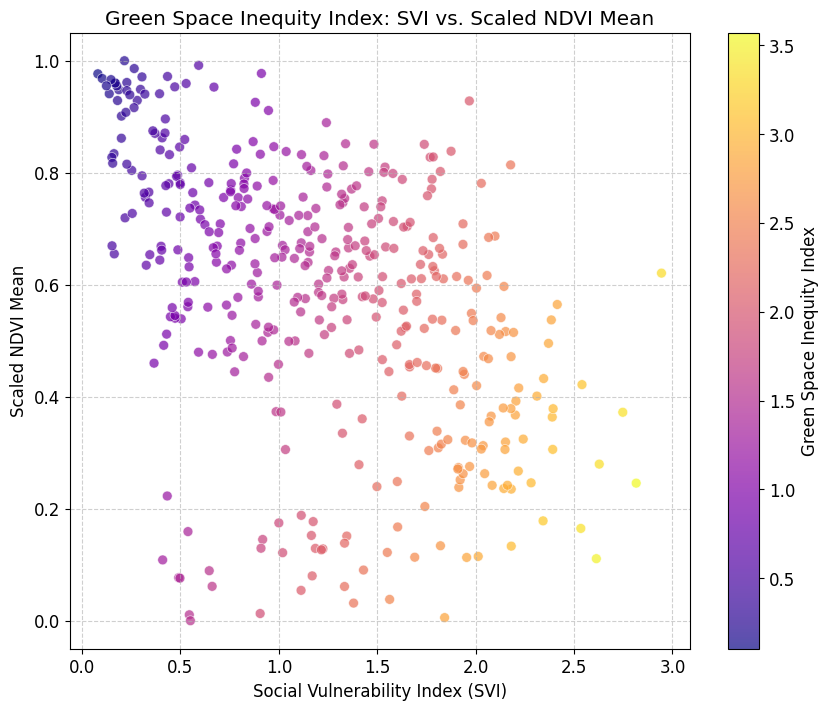

In [18]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Ensure ndvi_mean exists and handle potential NaN values if any rows had no NDVI data
# We'll fill NaNs with the mean of the existing ndvi_mean to allow scaling, or drop them.
# For an index, dropping might be more appropriate if a tract has no green space data.
# For now, let's fill with 0 so that missing NDVI is treated as no green space (high inequity contribution)
# Consider if 0 is the correct fill value or if dropping tracts with NaN NDVI is better for your analysis.
# For this example, let's fill with the global mean of ndvi_mean, which implies an average green space if data is missing.
# A more robust approach might be to drop rows with NaN in ndvi_mean for index calculation, or fill with a value that signifies 'unknown green space'.
# Let's drop rows for a cleaner index calculation if ndvi_mean is NaN.
gdf_cleaned = gdf.dropna(subset=['ndvi_mean']).copy() # Create a copy to avoid SettingWithCopyWarning

# Initialize MinMaxScaler for NDVI
ndvi_scaler = MinMaxScaler()

# Scale the ndvi_mean values
gdf_cleaned['scaled_ndvi_mean'] = ndvi_scaler.fit_transform(gdf_cleaned[['ndvi_mean']])

# Create the Green Space Inequity Index
# Higher SVI means higher social vulnerability.
# Lower NDVI means less green space, which contributes to inequity.
# So, (1 - scaled_ndvi_mean) represents 'lack of green space' on a 0-1 scale.
# Adding SVI and 'lack of green space' will give a combined inequity index.
gdf_cleaned['Green_Space_Inequity_Index'] = gdf_cleaned['SVI'] + (1 - gdf_cleaned['scaled_ndvi_mean'])

print("Green Space Inequity Index created. Here's a peek at the new columns and the index:")
print(gdf_cleaned[['SVI', 'scaled_ndvi_mean', 'Green_Space_Inequity_Index']].head())

# Plot the data on a scatter plot
# SVI vs. scaled_ndvi_mean, colored by the new Green Space Inequity Index
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    gdf_cleaned['SVI'],
    gdf_cleaned['scaled_ndvi_mean'], # Plot scaled_ndvi_mean directly on y-axis
    c=gdf_cleaned['Green_Space_Inequity_Index'],
    cmap='plasma', # Choose a colormap, e.g., 'viridis', 'plasma', 'magma'
    s=50, # Marker size
    alpha=0.7, # Transparency
    edgecolors='w', # White edges for markers
    linewidth=0.5
)
plt.colorbar(scatter, label='Green Space Inequity Index')
plt.title('Green Space Inequity Index: SVI vs. Scaled NDVI Mean') # Update title
plt.xlabel('Social Vulnerability Index (SVI)')
plt.ylabel('Scaled NDVI Mean') # Update y-axis label
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

####<font color="#FF69B4">PROMPT: Plot maps of SVI and the Green Space Inequity Index next to each other to compare</font>:

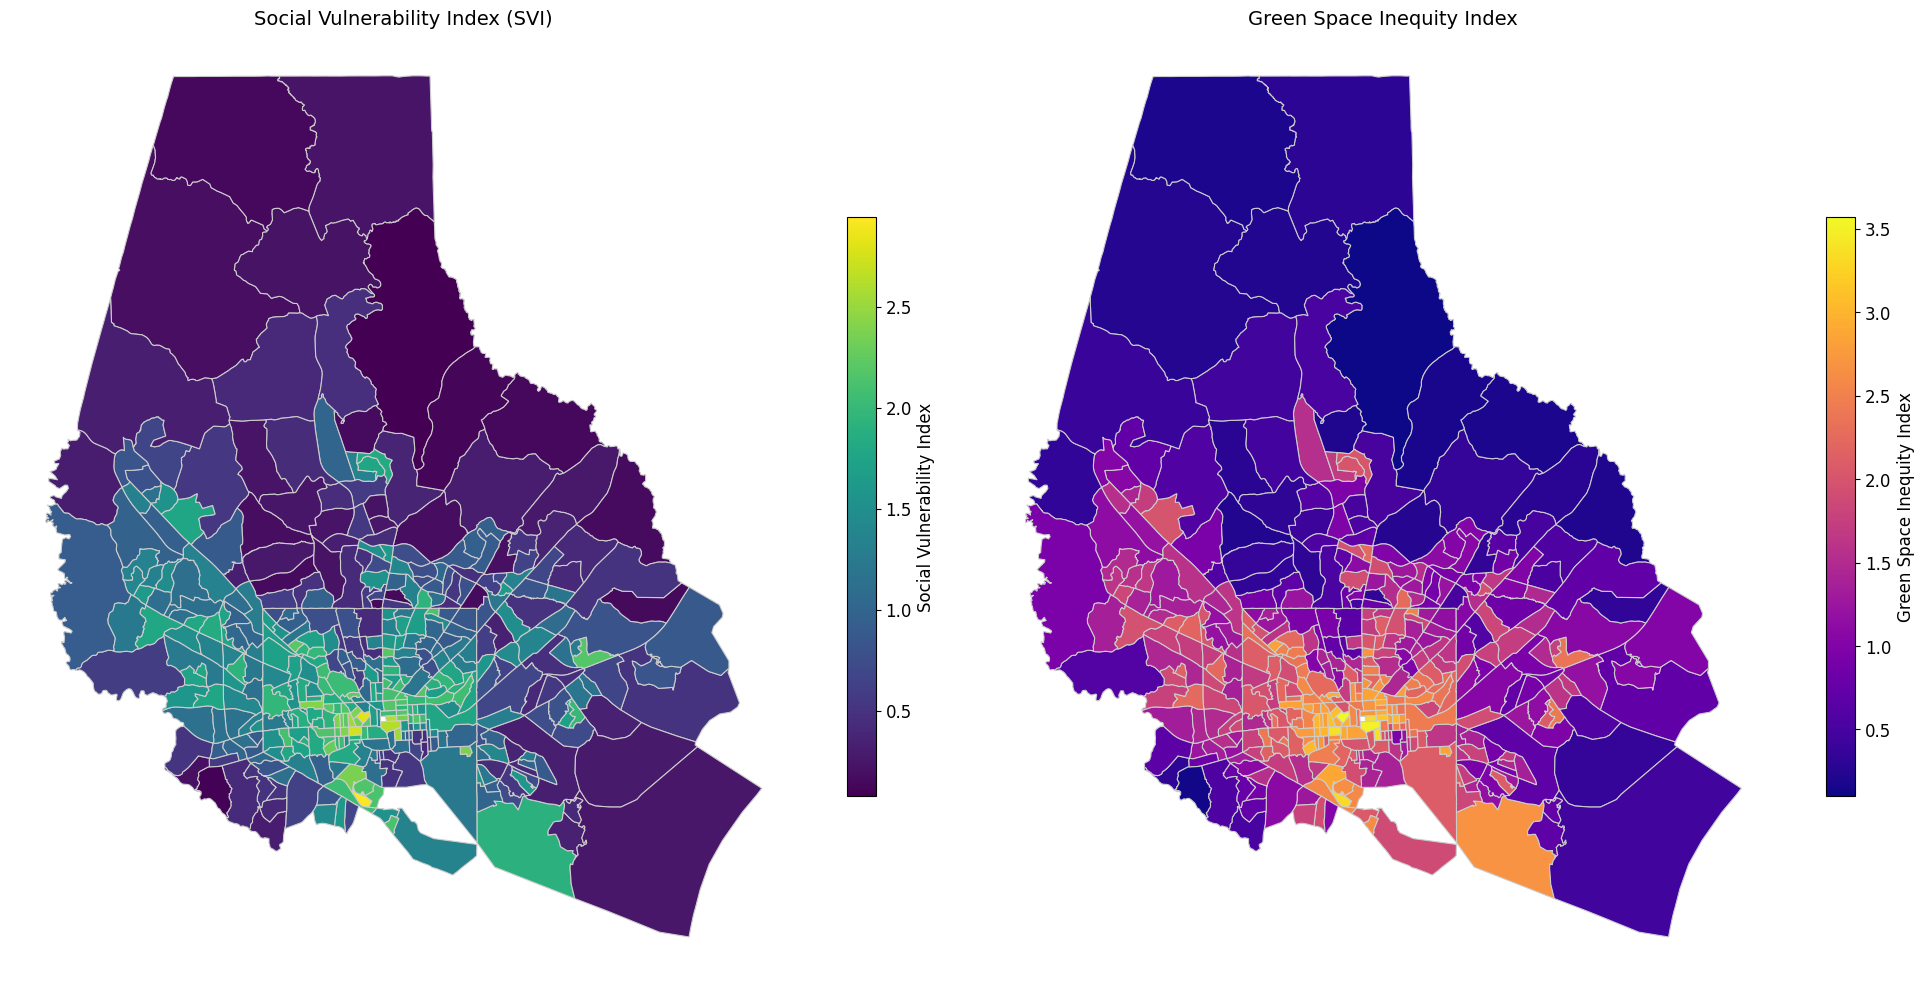

In [19]:
import matplotlib.pyplot as plt

# Set a global font size for better readability
plt.rcParams.update({'font.size': 12})

# Create subplots for the two maps
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Define common legend keywords for smaller colorbars and improved font size
legend_kwargs = {
    'orientation': "vertical",
    'shrink': 0.6,  # Reduce colorbar size relative to the plot
    'aspect': 20   # Control the width of the colorbar
}

# Plot SVI
gdf_cleaned.plot(column='SVI', cmap='viridis', linewidth=0.8, ax=axes[0], edgecolor='0.8',
                 legend=True, legend_kwds={**legend_kwargs, 'label': "Social Vulnerability Index"})
axes[0].set_title('Social Vulnerability Index (SVI)', fontsize=14)
axes[0].set_axis_off()

# Plot Green Space Inequity Index
gdf_cleaned.plot(column='Green_Space_Inequity_Index', cmap='plasma', linewidth=0.8, ax=axes[1], edgecolor='0.8',
                 legend=True, legend_kwds={**legend_kwargs, 'label': "Green Space Inequity Index"})
axes[1].set_title('Green Space Inequity Index', fontsize=14)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

####<font color="#FF69B4">PROMPT: Plot a correlation matrix for the variables that go into the green space inequity index?</font>


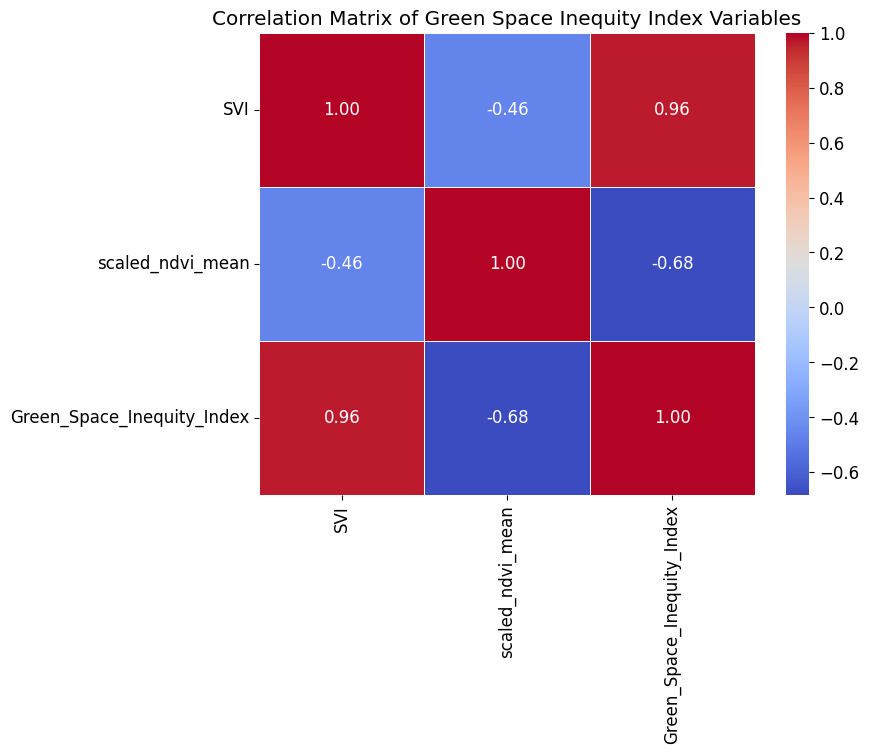

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the variables that go into the Green Space Inequity Index
# These are 'SVI', 'scaled_ndvi_mean', and 'Green_Space_Inequity_Index' itself.
# We use gdf_cleaned as it contains these calculated values and handles NaNs.
correlation_data = gdf_cleaned[['SVI', 'scaled_ndvi_mean', 'Green_Space_Inequity_Index']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True, # Show the correlation values on the heatmap
    cmap='coolwarm', # Choose a diverging colormap
    fmt=".2f", # Format annotation values to two decimal places
    linewidths=.5 # Add lines between cells
)
plt.title('Correlation Matrix of Green Space Inequity Index Variables')
plt.show()

####<font color="#FF69B4">PROMPT: Make a plot showing only the census tracts with the 10 highest environmental justice priority scores based on the green space inequity index?</font>:

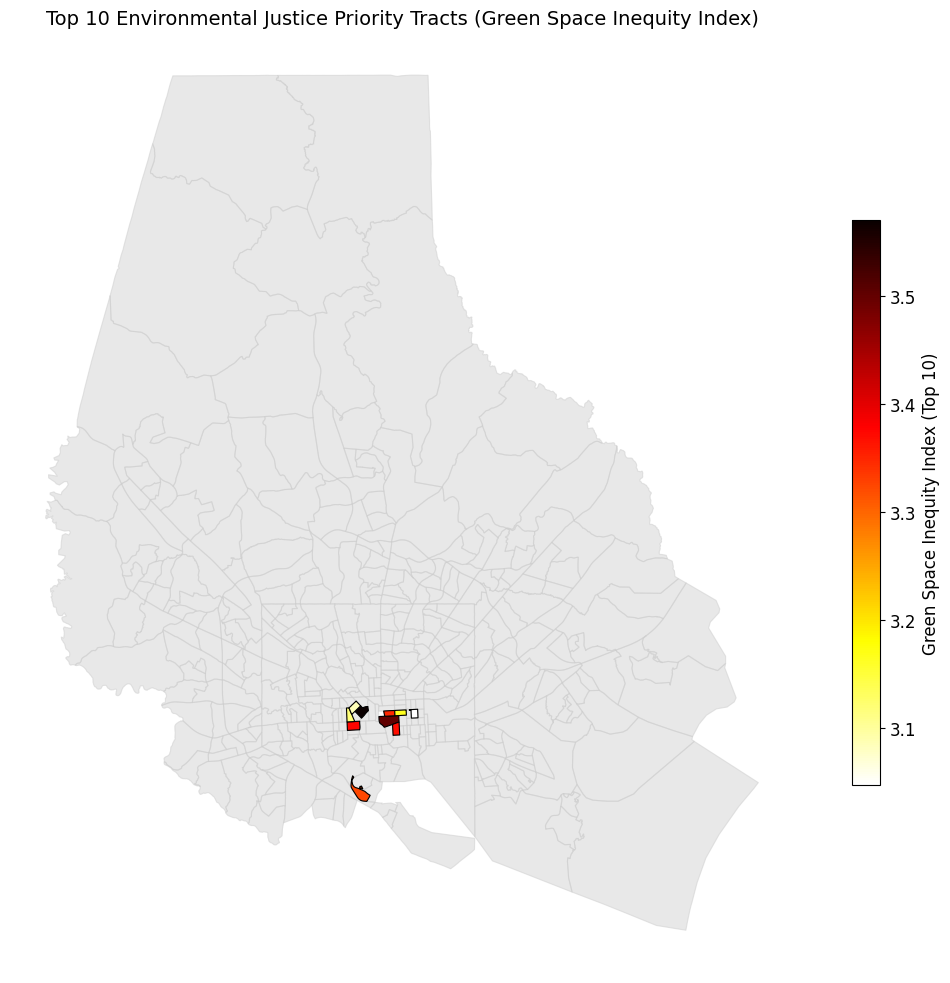

In [21]:
import matplotlib.pyplot as plt

# Sort the GeoDataFrame by 'Green_Space_Inequity_Index' in descending order
top_10_ej_tracts = gdf_cleaned.sort_values(by='Green_Space_Inequity_Index', ascending=False).head(10)

# Plotting the top 10 tracts
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Optionally, plot all other tracts in a very light color for context
gdf_cleaned.plot(color='lightgray', linewidth=0.8, ax=ax, edgecolor='0.8', alpha=0.5)

# Plot the top 10 environmental justice priority tracts
top_10_ej_tracts.plot(column='Green_Space_Inequity_Index', cmap='hot_r', linewidth=0.8, ax=ax, edgecolor='black',
                     legend=True,
                     legend_kwds={'label': "Green Space Inequity Index (Top 10)", 'orientation': "vertical", 'shrink': 0.6, 'aspect': 20})

ax.set_title('Top 10 Environmental Justice Priority Tracts (Green Space Inequity Index)', fontsize=14)
ax.set_axis_off() # Remove axes
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

# Ensure gdf_cleaned is available and contains the necessary columns
# If not, the previous cells for creating gdf_cleaned and calculating the index need to be run.

# Get the top 10 tracts based on 'Green_Space_Inequity_Index'
top_10_ej_tracts_breakdown = gdf_cleaned.sort_values(
    by='Green_Space_Inequity_Index', ascending=False
).head(10)

# Display the components for these top 10 tracts
print("Breakdown of SVI and Scaled NDVI Mean for Top 10 Green Space Inequity Tracts:")
print(top_10_ej_tracts_breakdown[[
    'SVI', 'scaled_ndvi_mean', 'Green_Space_Inequity_Index'
]].to_string())


Breakdown of SVI and Scaled NDVI Mean for Top 10 Green Space Inequity Tracts:
          SVI  scaled_ndvi_mean  Green_Space_Inequity_Index
328  2.815674          0.245696                    3.569978
231  2.613200          0.110821                    3.502379
271  2.747531          0.372258                    3.375272
91   2.534369          0.164825                    3.369544
262  2.628029          0.279659                    3.348370
48   2.944128          0.620739                    3.323389
127  2.342526          0.178319                    3.164207
60   2.540214          0.421631                    3.118584
94   2.391576          0.305944                    3.085632
125  2.180905          0.133187                    3.047718


## Wrap Up Discussion

- What are the key strengths and limitations of LLM-assisted coding analysis?
- Are there best practices for validating AI-generated code and maintaining reproducibility?



## Some Resources and References

- [NASA Harmonized Landsat Sentinel (HLS) Project](https://hls.gsfc.nasa.gov/)
- [US Census Bureau API](https://www.census.gov/data/developers/data-sets.html)
- [EPA's Environmental Justice Screening Tool (EJScreen)](https://www.epa.gov/ejscreen)
- [NASA SEDAC - Socioeconomic Data and Applications Center](https://sedac.ciesin.columbia.edu/)
- [LP DAAC - Getting Started with Cloud-Native HLS Data in Python](https://lpdaac.usgs.gov/resources/e-learning/getting-started-cloud-native-hls-data-python/)
- [Census Data API User Guide](https://www.census.gov/data/developers/guidance/api-user-guide.html)